In [1]:
import matplotlib.pyplot as plt
import xarray as xr

plt.rcParams.update(
    {
        "font.size": 14,
        "axes.titlesize": 16,
        "axes.labelsize": 14,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "legend.fontsize": 12,
    }
)

grid_path = "../plotting_data/0047_temp_mean_subset.nc"
orig_data = xr.open_dataset(grid_path)
lons = orig_data.lon.values
lats = orig_data.lat.values

Plotting pred_id-011_sample-10_CNRM-CM5_RegCM4-6_2090-2099_drought_metrics


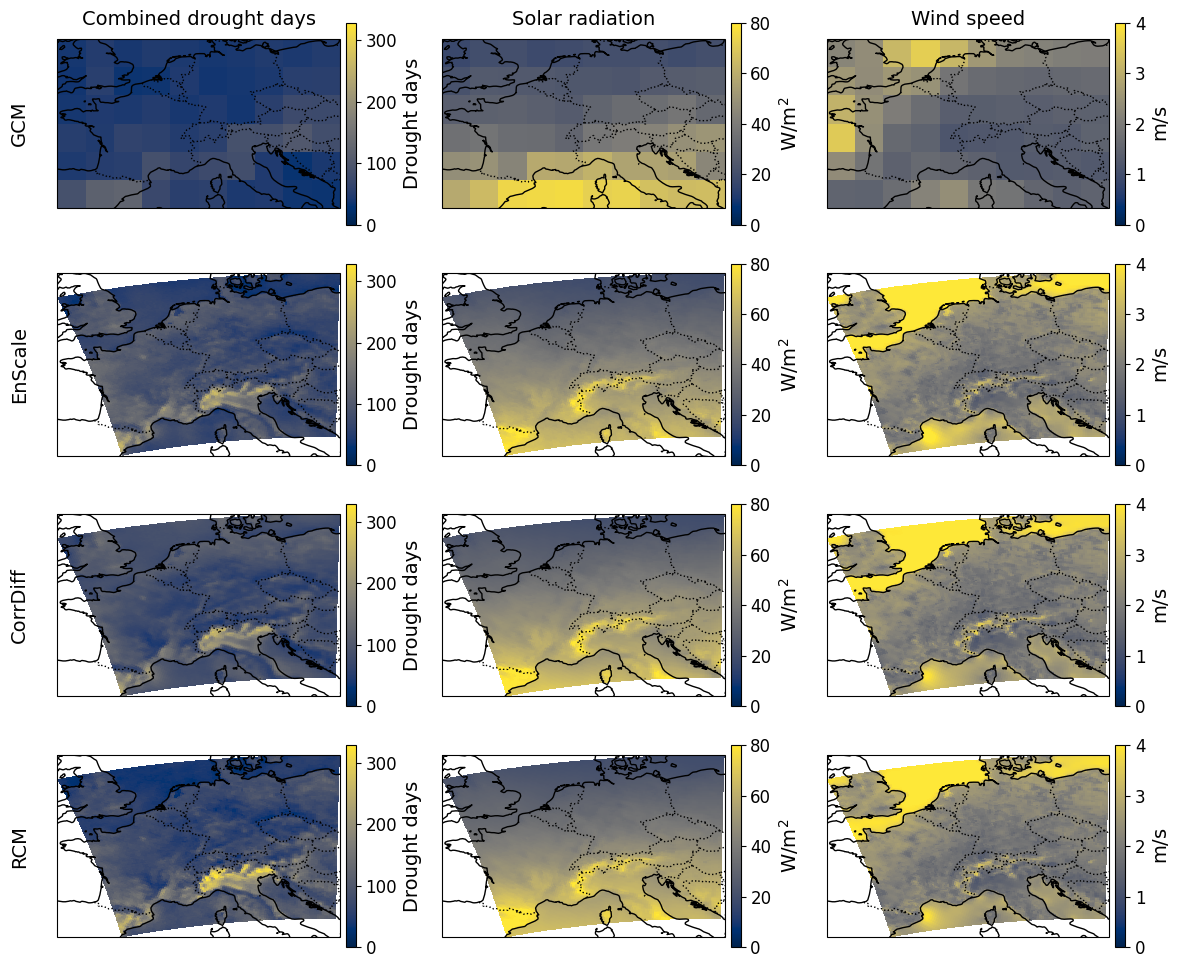

Saved ../plots/0105_enscale_vs_corrdiff_pred_id-011_sample-10_CNRM-CM5_RegCM4-6_2090-2099_drought_metrics.pdf


In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xarray as xr
import glob
import os

# Folder with single-model result files
data_folder = "../plotting_data/results_matrices/"
files = sorted(glob.glob(os.path.join(data_folder, "corrdiff_*.nc")))


def plot_panel(
    ax, data, lons, lats, cmap="cividis", label="Value", vmin=None, vmax=None
):
    im = ax.pcolormesh(
        lons,
        lats,
        data,
        cmap=cmap,
        shading="auto",
        transform=ccrs.PlateCarree(),
        vmin=vmin,
        vmax=vmax,
    )
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=":")
    cb = fig.colorbar(im, ax=ax, orientation="vertical", fraction=0.035, pad=0.02)
    cb.set_label(label)


vminmax = {"combined": (0, 0.09 * 3652), "solar": (0, 80), "wind": (0, 4)}

for file in files[2:3]:
    # Column headers
    ds = xr.open_dataset(file)
    name = os.path.basename(file).replace("corrdiff_", "").replace(".nc", "")
    print(f"Plotting {name}")
    ds_ens = xr.open_dataset(
        "../plotting_data/results_matrices/enscale/idx6_inter_drought_metrics.nc"
    )
    fig, axes = plt.subplots(
        4, 3, figsize=(12, 10), subplot_kw={"projection": ccrs.PlateCarree()}
    )
    axes = axes.reshape(4, 3)
    # Column headers
    col_titles = ["Combined drought days", "Solar radiation", "Wind speed"]
    for i, title in enumerate(col_titles):
        axes[0, i].set_title(title, pad=10, fontsize=14)

    # --- Row 1: GCM ---
    plot_panel(
        axes[0, 0],
        ds["combined_GCM"] * 3652,
        ds["combined_GCM"].lon,
        ds["combined_GCM"].lat,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        axes[0, 1],
        ds["solar_GCM"],
        ds["solar_GCM"].lon,
        ds["solar_GCM"].lat,
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        axes[0, 2],
        ds["wind_GCM"],
        ds["wind_GCM"].lon,
        ds["wind_GCM"].lat,
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[0, 0].text(
        -0.1,
        0.5,
        "GCM",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[0, 0].transAxes,
    )

    # --- Row 2: RCM emulated ---
    plot_panel(
        axes[1, 0],
        ds_ens["combined_RCM_emulated"] * 3652,
        lons,
        lats,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        axes[1, 1],
        ds_ens["solar_RCM_emulated"],
        lons,
        lats,
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        axes[1, 2],
        ds_ens["wind_RCM_emulated"],
        lons,
        lats,
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[1, 0].text(
        -0.1,
        0.5,
        "EnScale",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[1, 0].transAxes,
    )

    # --- Row 2: RCM emulated ---
    plot_panel(
        axes[2, 0],
        ds["combined_RCM_emulated"] * 3652,
        lons,
        lats,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        axes[2, 1],
        ds["solar_RCM_emulated"],
        lons,
        lats,
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        axes[2, 2],
        ds["wind_RCM_emulated"],
        lons,
        lats,
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[2, 0].text(
        -0.1,
        0.5,
        "CorrDiff",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[2, 0].transAxes,
    )

    # --- Row 3: RCM truth ---
    plot_panel(
        axes[3, 0],
        ds["combined_RCM_truth"] * 3652,
        lons,
        lats,
        label="Drought days",
        vmin=vminmax["combined"][0],
        vmax=vminmax["combined"][1],
    )
    plot_panel(
        axes[3, 1],
        ds["solar_RCM_truth"],
        lons,
        lats,
        label=r"$\mathrm{W/m^2}$",
        vmin=vminmax["solar"][0],
        vmax=vminmax["solar"][1],
    )
    plot_panel(
        axes[3, 2],
        ds["wind_RCM_truth"],
        lons,
        lats,
        label=r"$\mathrm{m/s}$",
        vmin=vminmax["wind"][0],
        vmax=vminmax["wind"][1],
    )
    axes[3, 0].text(
        -0.1,
        0.5,
        "RCM",
        va="center",
        ha="right",
        rotation=90,
        transform=axes[3, 0].transAxes,
    )

    plt.tight_layout()
    out_path = f"../plots/0105_enscale_vs_corrdiff_{name}.pdf"
    plt.savefig(out_path)
    plt.show()
    print(f"Saved {out_path}")